# Direct GPQR

In this example, the data generating process is
$$Y = \cos(2 \pi (X+0.1)) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, X+0.1),$$
and prior mean is
$$ \mu(x) = \cos(2 \pi X). $$

Quantile functions $Q_{\tau_i}(x)$ of residuals are modeled by linear combination of latent GP $g_j(x)$.

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import UnwhitenedVariationalStrategy
from gpytorch.variational import LMCVariationalStrategy
from gpytorch.means import Mean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.models import DirectQuantileGP
from gpytorch_qr.likelihoods import DirectQuantileLikelihood

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 10000))
n_epochs = 1

Output will not be deterministic SVG.


## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
x = x_range.repeat(5, 1)
y = (mean(x + 0.1) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
res = y - mean(x).squeeze(1)

q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9]).to(device)
true_quantiles = mean(x_range + 0.1) + std(x_range) * Normal(0, 1).icdf(q)
res_quantiles = true_quantiles - mean(x_range)

x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

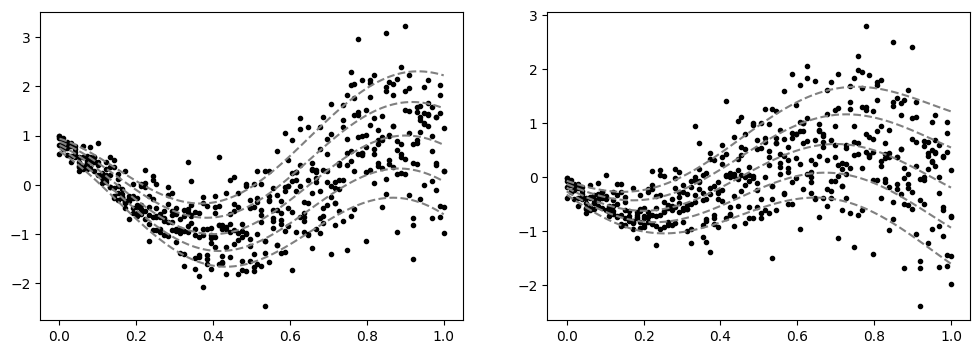

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x.cpu(), y.cpu(), c="k", marker=".")
axes[0].plot(x_range.cpu(), true_quantiles.cpu(), "--", c="gray")

axes[1].scatter(x.cpu(), res.cpu(), c="k", marker=".")
axes[1].plot(x_range.cpu(), res_quantiles.cpu(), "--", c="gray")

plt.show()